# Cociente de forma libre de escala en perfiles CBS

Este notebook extiende el test de autosimilitud mediante

$$\mathcal{S}=\frac{q_{0.25}}{q_{0.75}},$$

donde $q_x$ es el primer cruce descendente del exceso normalizado $[\eta(q)-1]/[\eta(0)-1]$ por el nivel $x$. Como ambos cruces pertenecen al mismo perfil, $\mathcal S$ no depende de la amplitud ni de una reescala global del eje angular. Se estudian: (1) familias teóricas de una y dos escalas; (2) medios homogéneos RGD; (3) medios homogéneos Mie; (4) mezclas binarias; y (5) bicapas con $\mu_s$ igualado.

En los datos, $\mathcal S$ se calcula por réplica. Las barras representan intervalos $t$ del 95 % sobre las réplicas, no incertidumbre bin a bin.

In [8]:
from pathlib import Path
from dataclasses import dataclass
import sys
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from scipy import stats
from IPython.display import display

# Localiza la raíz aunque el kernel no se abra exactamente desde plots/.
_candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents,
               Path('/Users/niaggar/Developer/luminis-mc')]
ROOT = next((p for p in _candidates if (p / 'utils').is_dir()), None)
if ROOT is None:
    raise FileNotFoundError('No se encontró la raíz de luminis-mc (carpeta utils/).')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from utils.loaders import load_sweep
from utils.analysis import cbs_profiles, linear, circular, phi_cut, azimuthal_average

RESULTS = Path('/Users/niaggar/Results')
FIGDIR = ROOT / 'plots' / 'figs_scale_free_ratio'
FIGDIR.mkdir(exist_ok=True)

N_MEDIUM, WAVELENGTH = 1.33, 0.514
K_MEDIUM = 2 * np.pi * N_MEDIUM / WAVELENGTH
EPS = 1e-30
CONF = 0.975
N_APEX = 5
Q_MIN_BASELINE = 25.0

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 10, 'axes.titlesize': 11, 'legend.fontsize': 8,
})
COLORS = {'linear': '#2a6fbb', 'circular': '#d95f02'}
MARKERS = {'linear': 's', 'circular': 'o'}
LABELS = {'linear': r'$I_\parallel$', 'circular': r'$I_+$'}
print('ROOT   =', ROOT)
print('FIGDIR =', FIGDIR)

ROOT   = /Users/niaggar/Developer/luminis-mc
FIGDIR = /Users/niaggar/Developer/luminis-mc/plots/figs_scale_free_ratio


## Estimador común

La línea base se lleva a uno usando la cola. El valor del ápice se extrapola con la cúspide lineal en los primeros cinco bins. Antes de invertir los niveles se impone una envolvente monótona decreciente, que evita cruces espurios debidos al ruido sin suavizar las posiciones de cruce.

In [9]:
@dataclass
class Group:
    x: float
    label: str
    keys: list

def _channel_get(profile, channel, which):
    obj = getattr(profile, which)
    try:
        return np.asarray(obj[channel], float)
    except (TypeError, KeyError):
        return np.asarray(getattr(obj, channel), float)

def _raw_profiles(sweep, key, basis):
    reducer = phi_cut(0) if basis is linear else azimuthal_average
    sw = sweep[key]
    p1 = cbs_profiles(sw.processed_cbs('farfield_cbs_1'), basis=basis,
                      time_index=0, reduce=reducer)
    p2 = cbs_profiles(sw.processed_cbs('farfield_cbs_2'), basis=basis,
                      time_index=0, reduce=reducer)
    return p1, p2

def _tail_baseline(q, y, q_min=Q_MIN_BASELINE, n_min=5, frac=0.85):
    q, y = np.asarray(q, float), np.asarray(y, float)
    mask = q > q_min
    if np.count_nonzero(mask) >= n_min:
        return float(np.median(y[mask]))
    mask = q >= frac * np.nanmax(q)
    if np.count_nonzero(mask) < n_min:
        mask = np.argsort(q)[-n_min:]
    return float(np.median(y[mask]))

def profile_one(sweep, key, basis, channel, l_scale=None):
    p1, p2 = _raw_profiles(sweep, key, basis)
    e1 = (_channel_get(p1, channel, 'coherent') + EPS) / (_channel_get(p1, channel, 'incoherent') + EPS)
    e2 = (_channel_get(p2, channel, 'coherent') + EPS) / (_channel_get(p2, channel, 'incoherent') + EPS)
    th1, th2 = np.asarray(p1.theta, float), np.asarray(p2.theta, float)
    keep2 = th2 > th1[-1]
    theta = np.concatenate([th1, th2[keep2]])
    eta = np.concatenate([e1, e2[keep2]])
    if l_scale is None:
        p = sweep[key].params_flat
        l_scale = float(p.get('transport_mean_free_path', p.get('lstar_sim')))
    q = K_MEDIUM * float(l_scale) * theta
    return q, eta - _tail_baseline(q, eta) + 1.0

def apex_value(q, eta, n=N_APEX):
    q, eta = np.asarray(q, float), np.asarray(eta, float)
    n = min(n, len(q))
    return float(np.polyfit(q[:n], eta[:n], 1)[1])

def normalized_excess(q, eta, monotone=True):
    eta0 = apex_value(q, eta)
    if not np.isfinite(eta0) or eta0 <= 1:
        return None
    y = (np.asarray(eta, float) - 1.0) / (eta0 - 1.0)
    return np.minimum.accumulate(y) if monotone else y

def level_q(q, eta, level):
    q = np.asarray(q, float)
    y = normalized_excess(q, eta)
    if y is None:
        return np.nan
    idx = np.flatnonzero(y <= level)
    idx = idx[idx > 0]
    if len(idx) == 0:
        return np.nan
    i = int(idx[0])
    if y[i] == y[i - 1]:
        return np.nan
    return float(q[i - 1] + (level - y[i - 1]) * (q[i] - q[i - 1]) / (y[i] - y[i - 1]))

def shape_ratio(q, eta):
    q025, q075 = level_q(q, eta, 0.25), level_q(q, eta, 0.75)
    return float(q025 / q075) if np.isfinite(q025) and np.isfinite(q075) and q075 > 0 else np.nan

U_GRID = np.linspace(0.0, 4.0, 321)

def normalized_shape(q, eta, u_grid=U_GRID):
    y = normalized_excess(q, eta)
    q_half = level_q(q, eta, 0.5)
    if y is None or not np.isfinite(q_half) or q_half <= 0:
        return np.full_like(u_grid, np.nan)
    return np.interp(u_grid, np.asarray(q, float) / q_half, y)

def mean_profile(sweep, keys, basis, channel, l_scale=None):
    q_ref, curves = None, []
    for key in sorted(keys):
        q, eta = profile_one(sweep, key, basis, channel, l_scale=l_scale)
        if q_ref is None:
            q_ref = q
        curves.append(eta if len(q) == len(q_ref) and np.allclose(q, q_ref)
                      else np.interp(q_ref, q, eta))
    return q_ref, np.mean(np.vstack(curves), axis=0)

def group_shape(sweep, keys, basis, channel, l_scale=None):
    return normalized_shape(*mean_profile(sweep, keys, basis, channel, l_scale=l_scale))

def collapse_spread(shapes):
    curves = np.vstack(shapes)
    mean = np.nanmean(curves, axis=0)
    return float(np.sqrt(np.nanmean((curves - mean)**2)))

def ratio_stats(sweep, keys, basis, channel, l_scale=None):
    values = []
    for key in sorted(keys):
        q, eta = profile_one(sweep, key, basis, channel, l_scale=l_scale)
        values.append(shape_ratio(q, eta))
    values = np.asarray(values, float)
    values = values[np.isfinite(values)]
    n = len(values)
    if n == 0:
        return np.nan, np.nan, 0, values
    ci = stats.t.ppf(CONF, n - 1) * values.std(ddof=1) / np.sqrt(n) if n > 1 else np.nan
    return float(values.mean()), float(ci), n, values

def groups_from_param(sweep, param, label_fn):
    by_value = {}
    for key in sweep.keys():
        p = sweep[key].params_flat
        if param not in p:
            continue
        value = float(p[param])
        by_value.setdefault(round(value, 10), []).append(key)
    return [Group(x=v, label=label_fn(v), keys=sorted(by_value[v])) for v in sorted(by_value)]

def save_figure(fig, stem):
    fig.savefig(FIGDIR / f'{stem}.pdf', bbox_inches='tight')
    fig.savefig(FIGDIR / f'{stem}.png', dpi=180, bbox_inches='tight')

## 1. Referencia teórica

Para una familia $1+A f(q/Q)$, $\mathcal S$ debe ser constante aunque cambien $A$ y $Q$. El contraejemplo suma dos escalas con peso variable; allí la normalización por $q_{1/2}$ no logra un colapso y $\mathcal S$ cambia.

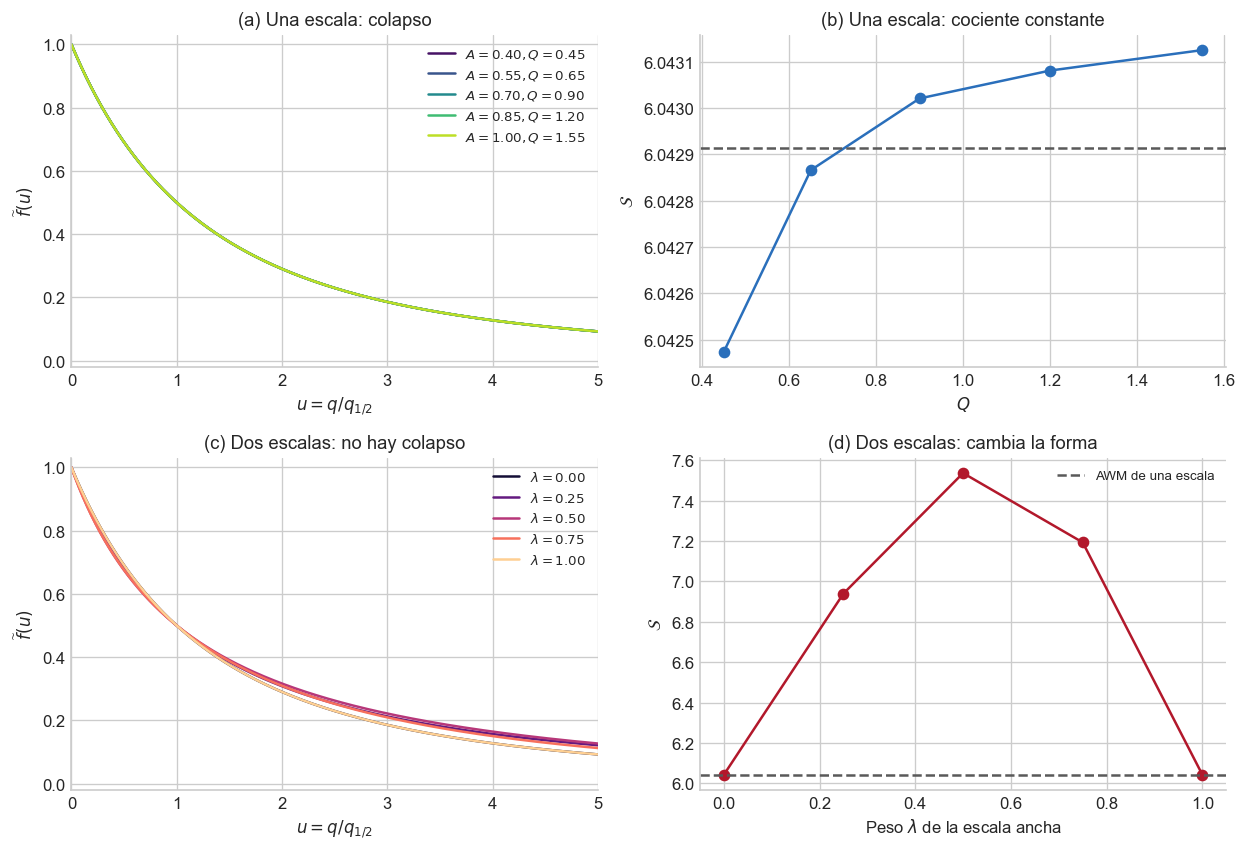

Referencia AWM: S = 6.04291


,family,parameter,S
0,one_scale,0.45,6.04247
1,one_scale,0.65,6.04287
2,one_scale,0.90,6.04302
3,one_scale,1.20,6.04308
4,one_scale,1.55,6.04313
5,two_scale,0.00,6.04247
6,two_scale,0.25,6.93989
7,two_scale,0.50,7.53652
8,two_scale,0.75,7.19328
9,two_scale,1.00,6.04313


In [10]:
def f_awm(x, zeta=2/3):
    x = np.asarray(x, float)
    ratio = np.empty_like(x)
    np.divide(-np.expm1(-2*zeta*x), x, out=ratio, where=x != 0)
    ratio = np.where(x == 0, 2*zeta, ratio)
    return ((1 + ratio) / (1 + x)**2) / (1 + 2*zeta)

q_theory = np.linspace(0, 8, 8001)
single_cfg = [(0.40, 0.45), (0.55, 0.65), (0.70, 0.90), (0.85, 1.20), (1.00, 1.55)]
weights = np.linspace(0, 1, 5)
single = []
two_scale = []
for A, Q in single_cfg:
    eta = 1 + A * f_awm(q_theory / Q)
    qh = level_q(q_theory, eta, 0.5)
    single.append((A, Q, q_theory/qh, normalized_excess(q_theory, eta), shape_ratio(q_theory, eta)))
for w in weights:
    eta = 1 + 0.8 * ((1-w)*f_awm(q_theory/0.45) + w*f_awm(q_theory/1.55))
    qh = level_q(q_theory, eta, 0.5)
    two_scale.append((w, q_theory/qh, normalized_excess(q_theory, eta), shape_ratio(q_theory, eta)))
S_AWM = float(np.mean([row[-1] for row in single]))

fig, axes = plt.subplots(2, 2, figsize=(10.5, 7.2))
for (A, Q, u, y, S), color in zip(single, plt.cm.viridis(np.linspace(.05, .9, len(single)))):
    axes[0,0].plot(u, y, color=color, label=rf'$A={A:.2f}, Q={Q:.2f}$')
axes[0,0].set(xlim=(0,5), ylim=(-.02,1.03), xlabel=r'$u=q/q_{1/2}$', ylabel=r'$\widetilde f(u)$', title='(a) Una escala: colapso')
axes[0,0].legend(frameon=False)
axes[0,1].plot([r[1] for r in single], [r[-1] for r in single], 'o-', color='#2a6fbb')
axes[0,1].axhline(S_AWM, color='0.35', ls='--')
axes[0,1].set(xlabel=r'$Q$', ylabel=r'$\mathcal{S}$', title='(b) Una escala: cociente constante')
for (w, u, y, S), color in zip(two_scale, plt.cm.magma(np.linspace(.1, .9, len(two_scale)))):
    axes[1,0].plot(u, y, color=color, label=rf'$\lambda={w:.2f}$')
axes[1,0].set(xlim=(0,5), ylim=(-.02,1.03), xlabel=r'$u=q/q_{1/2}$', ylabel=r'$\widetilde f(u)$', title='(c) Dos escalas: no hay colapso')
axes[1,0].legend(frameon=False)
axes[1,1].plot(weights, [r[-1] for r in two_scale], 'o-', color='#b2182b')
axes[1,1].axhline(S_AWM, color='0.35', ls='--', label='AWM de una escala')
axes[1,1].set(xlabel=r'Peso $\lambda$ de la escala ancha', ylabel=r'$\mathcal{S}$', title='(d) Dos escalas: cambia la forma')
axes[1,1].legend(frameon=False)
fig.tight_layout()
save_figure(fig, '01_scale_free_ratio_theory')
plt.show()

theory_df = pd.DataFrame({
    'family': ['one_scale']*len(single) + ['two_scale']*len(two_scale),
    'parameter': [r[1] for r in single] + [r[0] for r in two_scale],
    'S': [r[-1] for r in single] + [r[-1] for r in two_scale],
})
theory_df.to_csv(FIGDIR / 'scale_free_ratio_theory.csv', index=False)
print(f'Referencia AWM: S = {S_AWM:.5f}')
display(theory_df.round(5))

## 2. Medios homogéneos

Se usan las campañas `study_homog_timeresolved__PLIN__beam2500` y `study_homog_timeresolved__PCIR__beam2500`. El eje horizontal es el radio de partícula y la línea gris es la referencia AWM, no un ajuste a los datos.

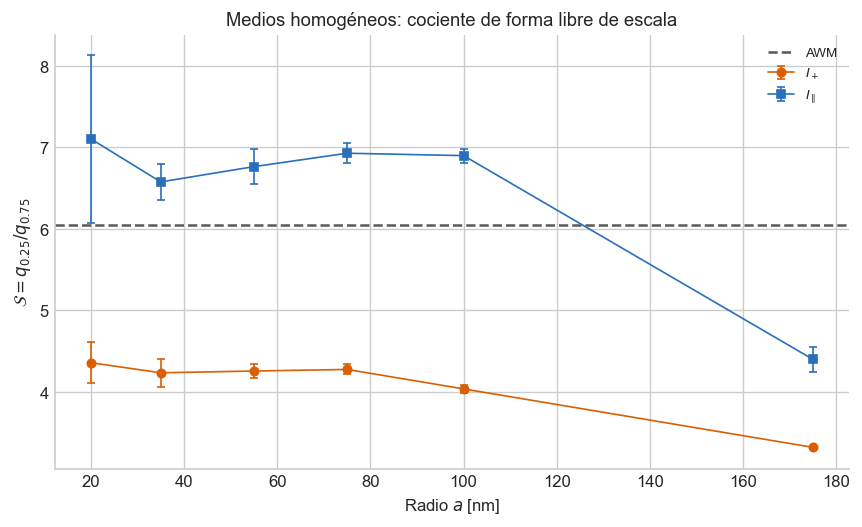

,polarization,radius_nm,S,ci95,n_valid
0,linear,20.0,7.1026,1.0328,5
1,linear,35.0,6.5745,0.2257,5
2,linear,55.0,6.7621,0.2169,5
3,linear,75.0,6.9265,0.1258,5
4,linear,100.0,6.8971,0.0857,5
5,linear,175.0,4.3967,0.1490,5
6,circular,20.0,4.3565,0.2499,5
7,circular,35.0,4.2325,0.1716,5
8,circular,55.0,4.2544,0.0907,5
9,circular,75.0,4.2736,0.0608,5


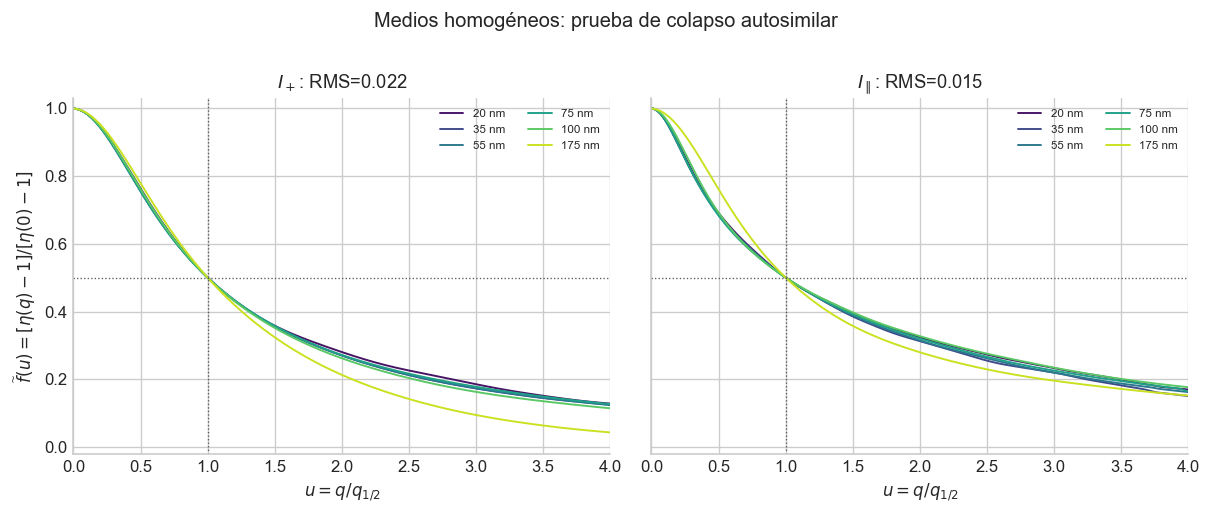

In [11]:
HOM_FOLDERS = {
    'linear': 'study_homog_timeresolved__PLIN__beam2500',
    'circular': 'study_homog_timeresolved__PCIR__beam2500',
}
HOM_DATA = {}
collapse_rows = []
hom_rows = []
for pol, folder in HOM_FOLDERS.items():
    sweep = load_sweep(folder, base_path=RESULTS)
    groups = groups_from_param(sweep, 'radius', lambda r: f'{1e3*r:.0f} nm')
    basis, channel = (linear, 'co') if pol == 'linear' else (circular, 'cross')
    HOM_DATA[pol] = (sweep, groups, basis, channel)
    for group in groups:
        mean, ci, n, values = ratio_stats(sweep, group.keys, basis, channel)
        hom_rows.append({'polarization': pol, 'radius_nm': 1e3*group.x,
                         'S': mean, 'ci95': ci, 'n_valid': n,
                         'S_replicates': values.tolist()})
hom_df = pd.DataFrame(hom_rows)
hom_df.drop(columns='S_replicates').to_csv(FIGDIR / 'scale_free_ratio_homogeneous.csv', index=False)

fig, ax = plt.subplots(figsize=(7.3, 4.5))
for pol in ('circular', 'linear'):
    d = hom_df[hom_df.polarization == pol]
    ax.errorbar(d.radius_nm, d.S, yerr=d.ci95, marker=MARKERS[pol], ms=5,
                capsize=2.5, lw=1, color=COLORS[pol], label=LABELS[pol])
ax.axhline(S_AWM, color='0.35', ls='--', label='AWM')
ax.set(xlabel=r'Radio $a$ [nm]', ylabel=r'$\mathcal{S}=q_{0.25}/q_{0.75}$',
       title='Medios homogéneos: cociente de forma libre de escala')
ax.legend(frameon=False)
fig.tight_layout()
save_figure(fig, '02_scale_free_ratio_homogeneous')
plt.show()
display(hom_df.drop(columns='S_replicates').round(4))

# Colapso autosimilar: se eliminan amplitud y escala angular.
fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.2), sharex=True, sharey=True)
for ax, pol in zip(axes, ('circular', 'linear')):
    sweep, groups, basis, channel = HOM_DATA[pol]
    shapes = []
    colors = plt.cm.viridis(np.linspace(0.05, 0.92, len(groups)))
    for color, group in zip(colors, groups):
        shape = group_shape(sweep, group.keys, basis, channel)
        shapes.append(shape)
        ax.plot(U_GRID, shape, color=color, lw=1.15, label=group.label)
    spread = collapse_spread(shapes)
    collapse_rows.append({'family': 'homogeneous', 'configuration': 'radius sweep',
                          'polarization': pol, 'collapse_rms': spread})
    ax.axvline(1, color='0.35', ls=':', lw=.8)
    ax.axhline(.5, color='0.35', ls=':', lw=.8)
    ax.set(xlim=(0, 4), ylim=(-.02, 1.03), xlabel=r'$u=q/q_{1/2}$',
           title=rf'{LABELS[pol]}: RMS={spread:.3f}')
    ax.legend(frameon=False, ncol=2, fontsize=7)
axes[0].set_ylabel(r'$\widetilde f(u)=[\eta(q)-1]/[\eta(0)-1]$')
fig.suptitle('Medios homogéneos: prueba de colapso autosimilar', y=1.01)
fig.tight_layout()
save_figure(fig, '02b_normalized_collapse_homogeneous')
plt.show()

## 3. Medios homogéneos con solución de Mie

Se repite exactamente el estimador anterior con las campañas `study_mie_same_Ls__PLIN__beam2500` y `study_mie_same_Ls__PCIR__beam2500`. Estas simulaciones usan `MieMedium`, cinco réplicas por radio y el mismo $\ell_s$ de referencia que el estudio RGD; el eje reducido de cada perfil usa el valor `lstar_sim` archivado para Mie. Se comparan directamente $\mathcal S$ y el colapso normalizado contra el caso RGD.

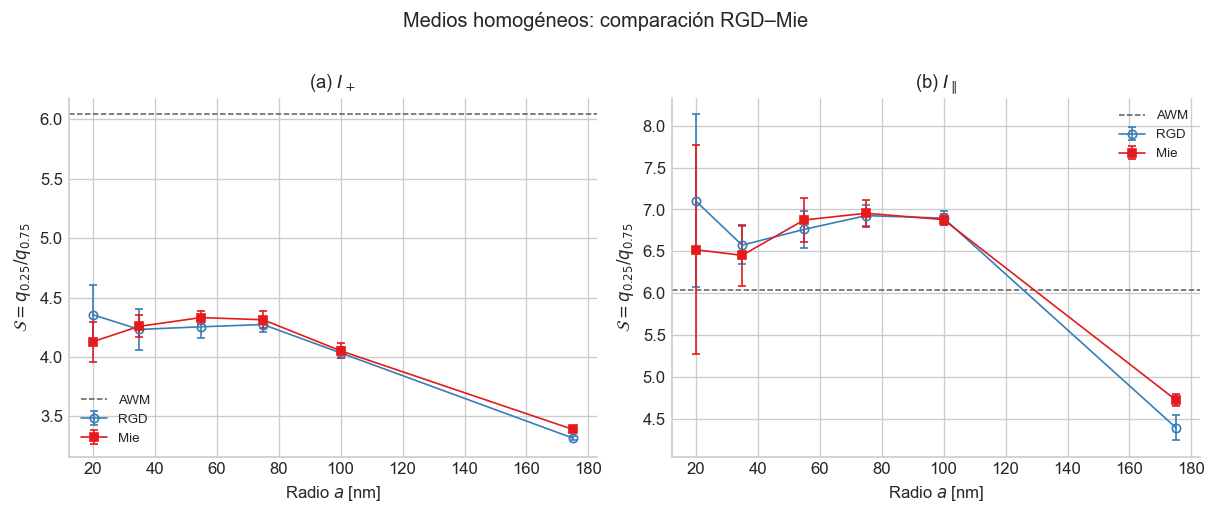

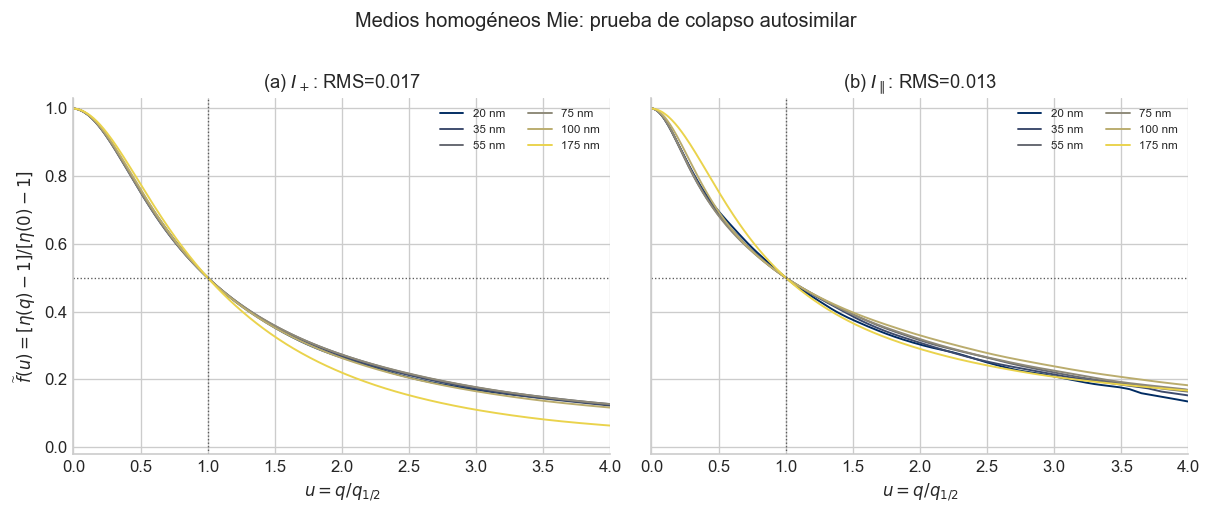

,polarization,radius_nm,S_mie,ci95_mie,n_valid_mie,S_rgd,ci95_rgd,n_valid_rgd,delta_S_mie_minus_rgd,ratio_S_mie_over_rgd
0,linear,20.0,6.5201,1.2448,5,7.1026,1.0328,5,-0.5825,0.9180
1,linear,35.0,6.4529,0.3646,5,6.5745,0.2257,5,-0.1216,0.9815
2,linear,55.0,6.8747,0.2574,5,6.7621,0.2169,5,0.1125,1.0166
3,linear,75.0,6.9549,0.1597,5,6.9265,0.1258,5,0.0283,1.0041
4,linear,100.0,6.8789,0.0659,5,6.8971,0.0857,5,-0.0182,0.9974
5,linear,175.0,4.7265,0.0672,5,4.3967,0.1490,5,0.3297,1.0750
6,circular,20.0,4.1287,0.1695,5,4.3565,0.2499,5,-0.2278,0.9477
7,circular,35.0,4.2581,0.0924,5,4.2325,0.1716,5,0.0256,1.0061
8,circular,55.0,4.3321,0.0526,5,4.2544,0.0907,5,0.0777,1.0183
9,circular,75.0,4.3138,0.0727,5,4.2736,0.0608,5,0.0402,1.0094


,polarization,radius_nm,medium_kind,g_mie,g_rgd_ref,l_s_um,lstar_mie_um,lstar_rgd_ref_um,lstar_ratio_mie_over_rgd,n_photons
0,linear,20.0,MieMedium,0.0173,0.0171,549.3307,559.0105,558.8752,1.0002,300000
1,linear,35.0,MieMedium,0.0567,0.0514,111.6658,118.3797,117.7206,1.0056,300000
2,linear,55.0,MieMedium,0.1371,0.1339,34.4770,39.9567,39.8094,1.0037,300000
3,linear,75.0,MieMedium,0.2642,0.2508,17.3533,23.5857,23.1635,1.0182,300000
4,linear,100.0,MieMedium,0.4837,0.4367,10.4640,20.2689,18.5767,1.0911,300000
5,linear,175.0,MieMedium,0.7659,0.7843,4.7910,20.4667,22.2100,0.9215,300000
6,circular,20.0,MieMedium,0.0186,0.0176,549.3307,559.7678,559.1991,1.0010,300000
7,circular,35.0,MieMedium,0.0546,0.0552,111.6658,118.1114,118.1914,0.9993,300000
8,circular,55.0,MieMedium,0.1397,0.1327,34.4770,40.0764,39.7500,1.0082,300000
9,circular,75.0,MieMedium,0.2657,0.2506,17.3533,23.6322,23.1549,1.0206,300000


In [12]:
MIE_FOLDERS = {
    'linear': 'study_mie_same_Ls__PLIN__beam2500',
    'circular': 'study_mie_same_Ls__PCIR__beam2500',
}
MIE_DATA, mie_rows, mie_param_rows = {}, [], []
for pol, folder in MIE_FOLDERS.items():
    sweep = load_sweep(folder, base_path=RESULTS)
    groups = groups_from_param(sweep, 'radius', lambda r: f'{1e3*r:.0f} nm')
    basis, channel = (linear, 'co') if pol == 'linear' else (circular, 'cross')
    MIE_DATA[pol] = (sweep, groups, basis, channel)
    assert all(len(g.keys) == 5 for g in groups), f'{pol}: se esperaban cinco réplicas por radio'
    assert {sweep[k].params_flat.get('medium_kind') for k in sweep.keys()} == {'MieMedium'}
    for group in groups:
        mean, ci, n, values = ratio_stats(sweep, group.keys, basis, channel)
        mie_rows.append({'polarization': pol, 'radius_nm': 1e3*group.x,
                         'S': mean, 'ci95': ci, 'n_valid': n,
                         'S_replicates': values.tolist()})
        p = sweep[group.keys[0]].params_flat
        mie_param_rows.append({'polarization': pol, 'radius_nm': 1e3*group.x,
                               'medium_kind': p.get('medium_kind'),
                               'g_mie': p.get('g_mie'), 'g_rgd_ref': p.get('g_rgd'),
                               'l_s_um': p.get('mean_free_path'),
                               'lstar_mie_um': p.get('lstar_sim'),
                               'lstar_rgd_ref_um': p.get('lstar_rgd_ref'),
                               'lstar_ratio_mie_over_rgd': p.get('lstar_ratio_sim_over_ref'),
                               'n_photons': p.get('n_photons')})
mie_df = pd.DataFrame(mie_rows)
mie_params_df = pd.DataFrame(mie_param_rows).drop_duplicates(['polarization', 'radius_nm'])
mie_df.drop(columns='S_replicates').to_csv(FIGDIR / 'scale_free_ratio_homogeneous_mie.csv', index=False)
mie_params_df.to_csv(FIGDIR / 'homogeneous_mie_parameters.csv', index=False)

# Comparación directa del cociente de forma: RGD frente a Mie.
fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.2), sharex=True, sharey=False)
for ax, pol, panel in zip(axes, ('circular', 'linear'), ('a', 'b')):
    for model, df, color, marker, fill in (
        ('RGD', hom_df, '#377eb8', 'o', 'none'),
        ('Mie', mie_df, '#e41a1c', 's', '#e41a1c'),
    ):
        d = df[df.polarization == pol]
        ax.errorbar(d.radius_nm, d.S, yerr=d.ci95, marker=marker, mfc=fill, mec=color,
                    ms=5, capsize=2.5, lw=1, color=color, label=model)
    ax.axhline(S_AWM, color='0.35', ls='--', lw=.9, label='AWM')
    ax.set(xlabel=r'Radio $a$ [nm]', ylabel=r'$\mathcal{S}=q_{0.25}/q_{0.75}$',
           title=rf'({panel}) {LABELS[pol]}')
    ax.legend(frameon=False)
fig.suptitle('Medios homogéneos: comparación RGD–Mie', y=1.01)
fig.tight_layout()
save_figure(fig, '02c_scale_free_ratio_homogeneous_rgd_vs_mie')
plt.show()

# Colapso autosimilar de la familia Mie.
fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.2), sharex=True, sharey=True)
for ax, pol, panel in zip(axes, ('circular', 'linear'), ('a', 'b')):
    sweep, groups, basis, channel = MIE_DATA[pol]
    shapes = []
    colors = plt.cm.cividis(np.linspace(0.05, 0.92, len(groups)))
    for color, group in zip(colors, groups):
        shape = group_shape(sweep, group.keys, basis, channel)
        shapes.append(shape)
        ax.plot(U_GRID, shape, color=color, lw=1.15, label=group.label)
    spread = collapse_spread(shapes)
    collapse_rows.append({'family': 'homogeneous_mie', 'configuration': 'radius sweep',
                          'polarization': pol, 'collapse_rms': spread})
    ax.axvline(1, color='0.35', ls=':', lw=.8)
    ax.axhline(.5, color='0.35', ls=':', lw=.8)
    ax.set(xlim=(0, 4), ylim=(-.02, 1.03), xlabel=r'$u=q/q_{1/2}$',
           title=rf'({panel}) {LABELS[pol]}: RMS={spread:.3f}')
    ax.legend(frameon=False, ncol=2, fontsize=7)
axes[0].set_ylabel(r'$\widetilde f(u)=[\eta(q)-1]/[\eta(0)-1]$')
fig.suptitle('Medios homogéneos Mie: prueba de colapso autosimilar', y=1.01)
fig.tight_layout()
save_figure(fig, '02d_normalized_collapse_homogeneous_mie')
plt.show()

mie_vs_rgd_df = mie_df.drop(columns='S_replicates').merge(
    hom_df.drop(columns='S_replicates'), on=['polarization', 'radius_nm'],
    suffixes=('_mie', '_rgd'))
mie_vs_rgd_df['delta_S_mie_minus_rgd'] = mie_vs_rgd_df.S_mie - mie_vs_rgd_df.S_rgd
mie_vs_rgd_df['ratio_S_mie_over_rgd'] = mie_vs_rgd_df.S_mie / mie_vs_rgd_df.S_rgd
mie_vs_rgd_df.to_csv(FIGDIR / 'scale_free_ratio_homogeneous_rgd_vs_mie.csv', index=False)
display(mie_vs_rgd_df.round(4))
display(mie_params_df.round(4))

## 4. Mezcla binaria

Se usan las campañas `study_mixture_layer__PLIN__beam2500` y `study_mixture_layer__PCIR__beam2500`. Aquí $\alpha=0$ y $\alpha=1$ son los dos controles monodispersos; los puntos interiores son las mezclas.

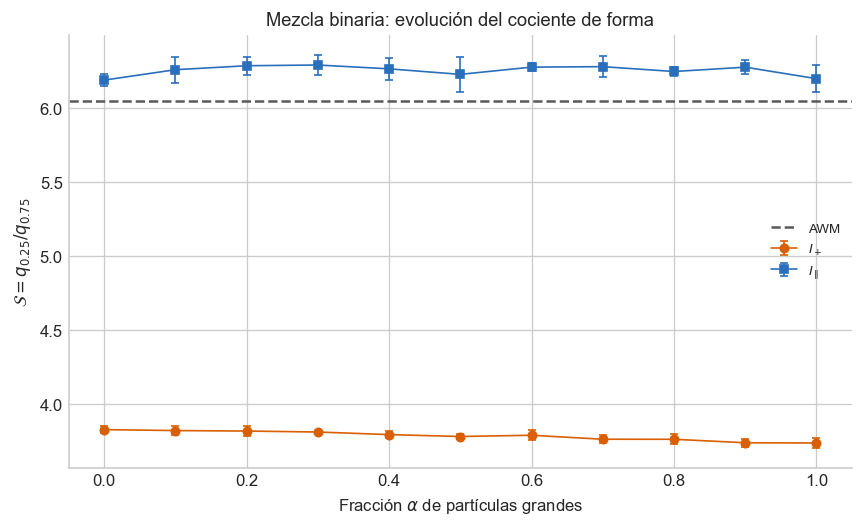

,polarization,alpha,S,ci95,n_valid
0,linear,0.0,6.1872,0.0394,5
1,linear,0.1,6.2574,0.0869,5
2,linear,0.2,6.2843,0.0610,5
3,linear,0.3,6.2891,0.0699,5
4,linear,0.4,6.2633,0.0754,5
5,linear,0.5,6.2260,0.1188,5
6,linear,0.6,6.2749,0.0269,5
7,linear,0.7,6.2780,0.0716,5
8,linear,0.8,6.2453,0.0291,5
9,linear,0.9,6.2746,0.0466,5


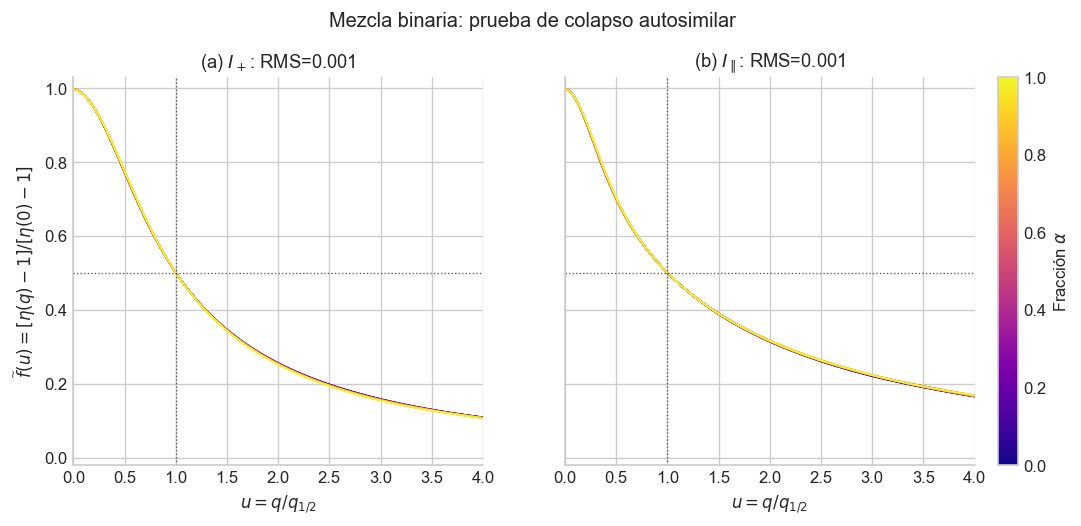

In [13]:
MIX_FOLDERS = {
    'linear': 'study_mixture_layer__PLIN__beam2500',
    'circular': 'study_mixture_layer__PCIR__beam2500',
}
MIX_DATA = {}
mix_rows = []
for pol, folder in MIX_FOLDERS.items():
    sweep = load_sweep(folder, base_path=RESULTS)
    groups = groups_from_param(sweep, 'fraction_x', lambda a: rf'$\alpha={a:.2f}$')
    basis, channel = (linear, 'co') if pol == 'linear' else (circular, 'cross')
    MIX_DATA[pol] = (sweep, groups, basis, channel)
    for group in groups:
        mean, ci, n, values = ratio_stats(sweep, group.keys, basis, channel)
        mix_rows.append({'polarization': pol, 'alpha': group.x,
                         'S': mean, 'ci95': ci, 'n_valid': n,
                         'S_replicates': values.tolist()})
mix_df = pd.DataFrame(mix_rows)
mix_df.drop(columns='S_replicates').to_csv(FIGDIR / 'scale_free_ratio_mixture.csv', index=False)

fig, ax = plt.subplots(figsize=(7.3, 4.5))
for pol in ('circular', 'linear'):
    d = mix_df[mix_df.polarization == pol]
    ax.errorbar(d.alpha, d.S, yerr=d.ci95, marker=MARKERS[pol], ms=5,
                capsize=2.5, lw=1, color=COLORS[pol], label=LABELS[pol])
ax.axhline(S_AWM, color='0.35', ls='--', label='AWM')
ax.set(xlabel=r'Fracción $\alpha$ de partículas grandes',
       ylabel=r'$\mathcal{S}=q_{0.25}/q_{0.75}$',
       title='Mezcla binaria: evolución del cociente de forma')
ax.legend(frameon=False)
fig.tight_layout()
save_figure(fig, '03_scale_free_ratio_mixture')
plt.show()
display(mix_df.drop(columns='S_replicates').round(4))

# Colapso autosimilar para toda la familia de composiciones.
fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.2), sharex=True, sharey=True)
alpha_norm = Normalize(vmin=0.0, vmax=1.0)
for ax, pol, panel in zip(axes, ('circular', 'linear'), ('a', 'b')):
    sweep, groups, basis, channel = MIX_DATA[pol]
    shapes = []
    for group in groups:
        shape = group_shape(sweep, group.keys, basis, channel)
        shapes.append(shape)
        ax.plot(U_GRID, shape, color=plt.cm.plasma(alpha_norm(group.x)), lw=1.0)
    spread = collapse_spread(shapes)
    collapse_rows.append({'family': 'mixture', 'configuration': 'alpha sweep',
                          'polarization': pol, 'collapse_rms': spread})
    ax.axvline(1, color='0.35', ls=':', lw=.8)
    ax.axhline(.5, color='0.35', ls=':', lw=.8)
    ax.set(xlim=(0, 4), ylim=(-.02, 1.03), xlabel=r'$u=q/q_{1/2}$',
           title=rf'({panel}) {LABELS[pol]}: RMS={spread:.3f}')
axes[0].set_ylabel(r'$\widetilde f(u)=[\eta(q)-1]/[\eta(0)-1]$')
sm_alpha = plt.cm.ScalarMappable(norm=alpha_norm, cmap='plasma')
cbar_alpha = fig.colorbar(sm_alpha, ax=axes, fraction=.025, pad=.025)
cbar_alpha.set_label(r'Fracción $\alpha$')
fig.suptitle('Mezcla binaria: prueba de colapso autosimilar', y=1.01)
save_figure(fig, '03b_normalized_collapse_mixture')
plt.show()

## 5. Bicapas con $\mu_s$ igualado

Se comparan los órdenes normal (partícula pequeña en la entrada) e inverso (partícula grande en la entrada) contra $d/\ell_s$, que es común a ambas especies en estas campañas. Las bandas de color delimitan, para cada polarización, los valores de los dos controles homogéneos archivados en la misma campaña.

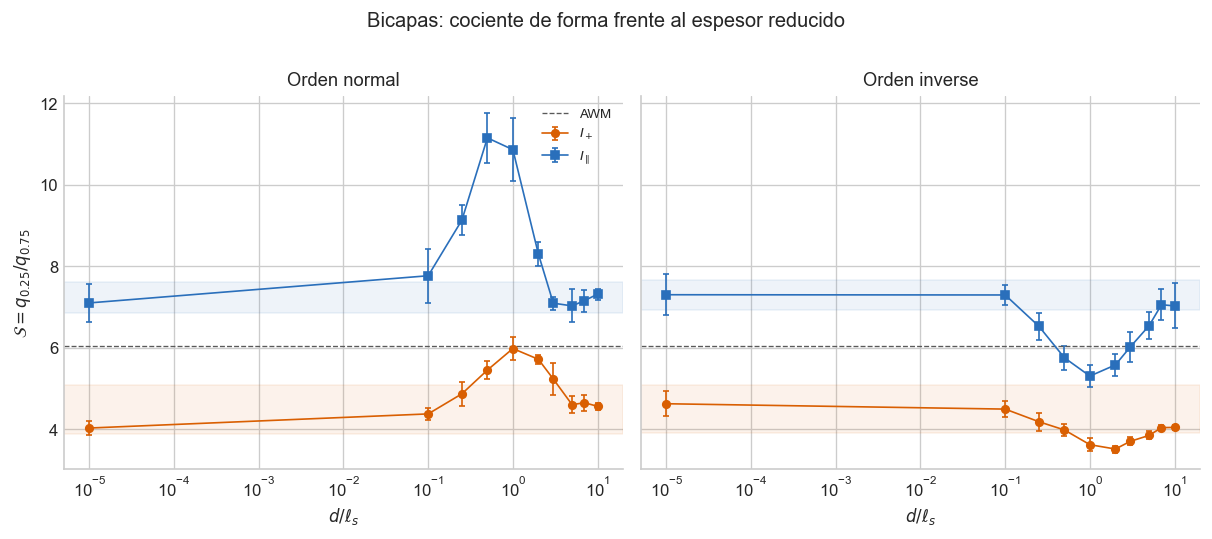

,order,polarization,d_over_ls,S,ci95,n_valid
0,normal,linear,0.00,7.1027,0.4685,5
1,normal,linear,0.10,7.7697,0.6660,5
2,normal,linear,0.25,9.1357,0.3694,5
3,normal,linear,0.50,11.1556,0.6114,5
4,normal,linear,1.00,10.8658,0.7749,5
5,normal,linear,2.00,8.3031,0.2919,5
6,normal,linear,3.00,7.0962,0.1582,5
7,normal,linear,5.00,7.0292,0.4034,5
8,normal,linear,7.00,7.1586,0.2717,5
9,normal,linear,10.00,7.3177,0.1362,5


,order,polarization,species,S,ci95,n_valid
0,normal,linear,small,7.4702,0.1511,5
1,normal,linear,large,7.1205,0.2770,5
2,normal,circular,small,4.7532,0.3240,5
3,normal,circular,large,4.0609,0.1676,5
4,inverse,linear,small,7.4040,0.2555,5
5,inverse,linear,large,7.1756,0.2432,5
6,inverse,circular,small,4.7648,0.3104,5
7,inverse,circular,large,4.0660,0.1684,5


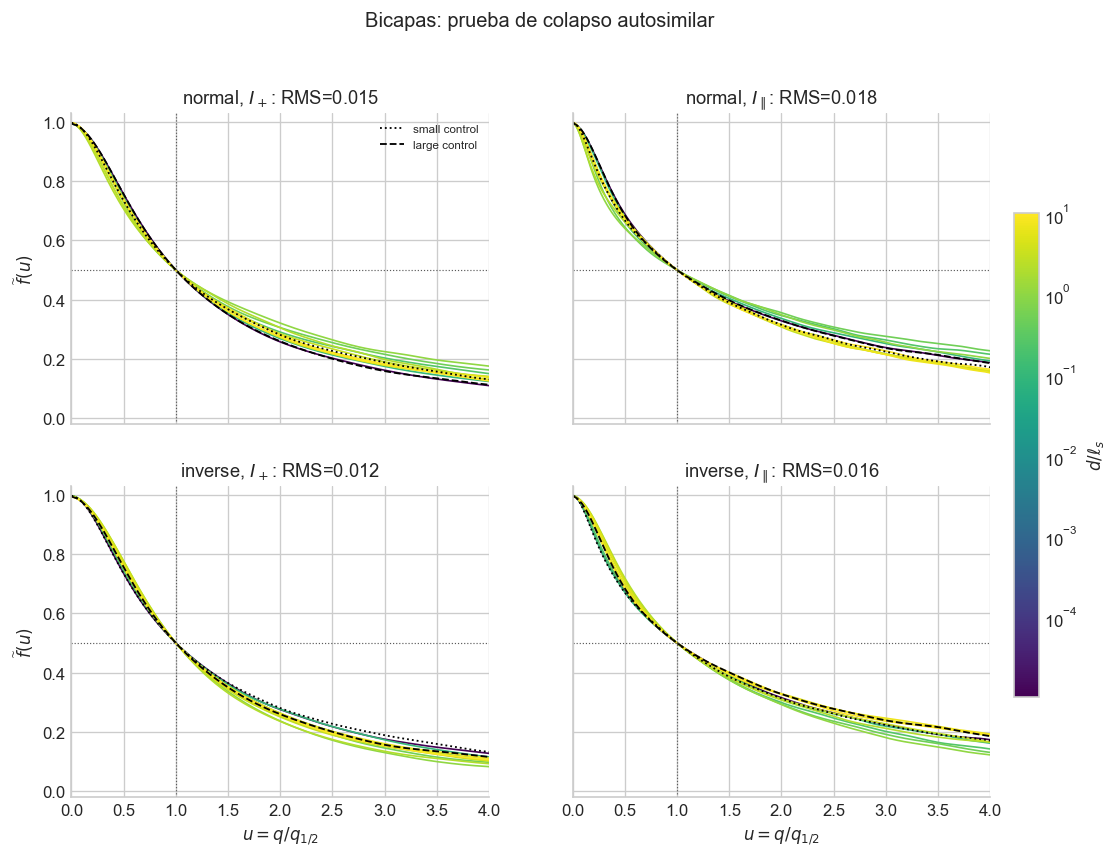

In [14]:
LAYER_FOLDERS = {
    ('normal', 'linear'): 'study_two_layers_MUS__NORMAL__PLIN__beam2500',
    ('normal', 'circular'): 'study_two_layers_MUS__NORMAL__PCIR__beam2500',
    ('inverse', 'linear'): 'study_two_layers_MUS__INVERSE__PLIN__beam2500',
    ('inverse', 'circular'): 'study_two_layers_MUS__INVERSE__PCIR__beam2500',
}
LAYER_DATA = {}

def layer_campaign_groups(sweep):
    layers, controls = {}, {'small': [], 'large': []}
    p_layer = None
    for key in sweep.keys():
        p = sweep[key].params_flat
        if p.get('layer_kind') == 'stratified_one_layer' or 'single_layer' in key:
            species = p.get('single_layer_species')
            if not species:
                species = 'small' if 'small' in key else 'large'
            controls[species].append(key)
        else:
            p_layer = p
            z = float(p.get('z_interface'))
            layers.setdefault(round(z, 8), []).append(key)
    if p_layer is None:
        raise RuntimeError('No se encontraron perfiles de bicapa.')
    l_anchor = float(p_layer['l_star_angle_anchor'])
    ls = 0.5 * (float(p_layer['l_s_top']) + float(p_layer['l_s_bot']))
    return [Group(x=z/ls, label=rf'$d/\ell_s={z/ls:.3g}$', keys=sorted(layers[z]))
            for z in sorted(layers)], {k: sorted(v) for k, v in controls.items()}, l_anchor

layer_rows, control_rows = [], []
for (order, pol), folder in LAYER_FOLDERS.items():
    sweep = load_sweep(folder, base_path=RESULTS)
    groups, controls, l_anchor = layer_campaign_groups(sweep)
    basis, channel = (linear, 'co') if pol == 'linear' else (circular, 'cross')
    LAYER_DATA[(order, pol)] = (sweep, groups, controls, l_anchor, basis, channel)
    for group in groups:
        mean, ci, n, values = ratio_stats(sweep, group.keys, basis, channel, l_scale=l_anchor)
        layer_rows.append({'order': order, 'polarization': pol, 'd_over_ls': group.x,
                           'S': mean, 'ci95': ci, 'n_valid': n,
                           'S_replicates': values.tolist()})
    for species, keys in controls.items():
        mean, ci, n, values = ratio_stats(sweep, keys, basis, channel, l_scale=l_anchor)
        control_rows.append({'order': order, 'polarization': pol, 'species': species,
                             'S': mean, 'ci95': ci, 'n_valid': n,
                             'S_replicates': values.tolist()})
layer_df = pd.DataFrame(layer_rows)
control_df = pd.DataFrame(control_rows)
layer_df.drop(columns='S_replicates').to_csv(FIGDIR / 'scale_free_ratio_bilayer.csv', index=False)
control_df.drop(columns='S_replicates').to_csv(FIGDIR / 'scale_free_ratio_bilayer_controls.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.4), sharey=True)
for ax, order in zip(axes, ('normal', 'inverse')):
    for pol in ('circular', 'linear'):
        d = layer_df[(layer_df.order == order) & (layer_df.polarization == pol)]
        c = control_df[(control_df.order == order) & (control_df.polarization == pol)]
        lo = float(np.min(c.S - c.ci95)); hi = float(np.max(c.S + c.ci95))
        ax.axhspan(lo, hi, color=COLORS[pol], alpha=0.08)
        ax.errorbar(d.d_over_ls, d.S, yerr=d.ci95, marker=MARKERS[pol], ms=4.5,
                    capsize=2, lw=1, color=COLORS[pol], label=LABELS[pol])
    ax.axhline(S_AWM, color='0.35', ls='--', lw=.8, label='AWM' if order == 'normal' else None)
    ax.set_xscale('log')
    ax.set(xlabel=r'$d/\ell_s$', title=f'Orden {order}')
axes[0].set_ylabel(r'$\mathcal{S}=q_{0.25}/q_{0.75}$')
axes[0].legend(frameon=False)
fig.suptitle(r'Bicapas: cociente de forma frente al espesor reducido', y=1.01)
fig.tight_layout()
save_figure(fig, '04_scale_free_ratio_bilayer')
plt.show()
display(layer_df.drop(columns='S_replicates').round(4))
display(control_df.drop(columns='S_replicates').round(4))

# Colapso autosimilar para las cuatro familias de bicapas.
all_m = np.array([g.x for data in LAYER_DATA.values() for g in data[1]], float)
m_norm = LogNorm(vmin=all_m[all_m > 0].min(), vmax=all_m.max())
fig, axes = plt.subplots(2, 2, figsize=(10.4, 7.4), sharex=True, sharey=True)
for row, order in enumerate(('normal', 'inverse')):
    for col, pol in enumerate(('circular', 'linear')):
        ax = axes[row, col]
        sweep, groups, controls, l_anchor, basis, channel = LAYER_DATA[(order, pol)]
        shapes = []
        for group in groups:
            shape = group_shape(sweep, group.keys, basis, channel, l_scale=l_anchor)
            shapes.append(shape)
            ax.plot(U_GRID, shape, color=plt.cm.viridis(m_norm(group.x)), lw=1.0)
        spread = collapse_spread(shapes)
        collapse_rows.append({'family': 'bilayer', 'configuration': order,
                              'polarization': pol, 'collapse_rms': spread})
        for species, ls in (('small', ':'), ('large', '--')):
            control_shape = group_shape(sweep, controls[species], basis, channel, l_scale=l_anchor)
            ax.plot(U_GRID, control_shape, color='black', ls=ls, lw=1.1,
                    label=f'{species} control')
        ax.axvline(1, color='0.35', ls=':', lw=.7)
        ax.axhline(.5, color='0.35', ls=':', lw=.7)
        ax.set(xlim=(0, 4), ylim=(-.02, 1.03),
               title=rf'{order}, {LABELS[pol]}: RMS={spread:.3f}')
        if row == 1:
            ax.set_xlabel(r'$u=q/q_{1/2}$')
        if col == 0:
            ax.set_ylabel(r'$\widetilde f(u)$')
axes[0,0].legend(frameon=False, fontsize=7)
sm = plt.cm.ScalarMappable(norm=m_norm, cmap='viridis')
cbar = fig.colorbar(sm, ax=axes, fraction=.025, pad=.025)
cbar.set_label(r'$d/\ell_s$')
fig.suptitle('Bicapas: prueba de colapso autosimilar', y=.995)
save_figure(fig, '04b_normalized_collapse_bilayer')
plt.show()

## 6. Resumen numérico y lectura

Se resume el rango observado en cada familia. Un valor aproximadamente constante de $\mathcal S$ es compatible con una forma de una sola escala, pero no la demuestra. Una excursión respecto a los controles homogéneos indica un cambio de forma; debe interpretarse junto con los intervalos entre réplicas y el test completo de colapso, no solo con la referencia AWM.

In [15]:
summary_rows = [
    {'family': 'theory_one_scale', 'configuration': 'AWM', 'polarization': '-',
     'S_min': min(r[-1] for r in single), 'S_max': max(r[-1] for r in single)},
    {'family': 'theory_two_scale', 'configuration': 'AWM mixture', 'polarization': '-',
     'S_min': min(r[-1] for r in two_scale), 'S_max': max(r[-1] for r in two_scale)},
]
for pol, d in hom_df.groupby('polarization'):
    summary_rows.append({'family': 'homogeneous', 'configuration': 'radius sweep',
                         'polarization': pol, 'S_min': d.S.min(), 'S_max': d.S.max()})
for pol, d in mie_df.groupby('polarization'):
    summary_rows.append({'family': 'homogeneous_mie', 'configuration': 'radius sweep',
                         'polarization': pol, 'S_min': d.S.min(), 'S_max': d.S.max()})
for pol, d in mix_df.groupby('polarization'):
    summary_rows.append({'family': 'mixture', 'configuration': 'alpha sweep',
                         'polarization': pol, 'S_min': d.S.min(), 'S_max': d.S.max()})
for (order, pol), d in layer_df.groupby(['order', 'polarization']):
    summary_rows.append({'family': 'bilayer', 'configuration': order,
                         'polarization': pol, 'S_min': d.S.min(), 'S_max': d.S.max()})
summary = pd.DataFrame(summary_rows)
summary['relative_span_percent'] = 100 * (summary.S_max / summary.S_min - 1)
summary.to_csv(FIGDIR / 'scale_free_ratio_summary.csv', index=False)
display(summary.round(4))
collapse_df = pd.DataFrame(collapse_rows)
collapse_df.to_csv(FIGDIR / 'normalized_collapse_summary.csv', index=False)
display(collapse_df.round(5))

assert hom_df.n_valid.min() >= 2
assert mix_df.n_valid.min() >= 2
assert layer_df.n_valid.min() >= 2
assert np.all(np.isfinite(summary[['S_min', 'S_max']]))
print('Verificación completa: todos los grupos tienen al menos dos réplicas válidas.')
print('Artefactos:')
for path in sorted(FIGDIR.glob('*')):
    print(f'  {path.name:48s} {path.stat().st_size/1024:8.1f} kB')

,family,configuration,polarization,S_min,S_max,relative_span_percent
0,theory_one_scale,AWM,-,6.0425,6.0431,0.0108
1,theory_two_scale,AWM mixture,-,6.0425,7.5365,24.7258
2,homogeneous,radius sweep,circular,3.3176,4.3565,31.3163
3,homogeneous,radius sweep,linear,4.3967,7.1026,61.5428
4,homogeneous_mie,radius sweep,circular,3.3908,4.3321,27.7615
5,homogeneous_mie,radius sweep,linear,4.7265,6.9549,47.1472
6,mixture,alpha sweep,circular,3.7376,3.8281,2.4201
7,mixture,alpha sweep,linear,6.1872,6.2891,1.6467
8,bilayer,inverse,circular,3.5139,4.6262,31.6558
9,bilayer,inverse,linear,5.3058,7.3033,37.6490


,family,configuration,polarization,collapse_rms
0,homogeneous,radius sweep,circular,0.02183
1,homogeneous,radius sweep,linear,0.01467
2,homogeneous_mie,radius sweep,circular,0.01721
3,homogeneous_mie,radius sweep,linear,0.01309
4,mixture,alpha sweep,circular,0.00107
5,mixture,alpha sweep,linear,0.00099
6,bilayer,normal,circular,0.01538
7,bilayer,normal,linear,0.01801
8,bilayer,inverse,circular,0.01161
9,bilayer,inverse,linear,0.01604


Verificación completa: todos los grupos tienen al menos dos réplicas válidas.
Artefactos:
  01_scale_free_ratio_theory.pdf                       37.3 kB
  01_scale_free_ratio_theory.png                      191.5 kB
  02_scale_free_ratio_homogeneous.pdf                  24.6 kB
  02_scale_free_ratio_homogeneous.png                  56.8 kB
  02b_normalized_collapse_homogeneous.pdf              31.5 kB
  02b_normalized_collapse_homogeneous.png             129.6 kB
  02c_scale_free_ratio_homogeneous_rgd_vs_mie.pdf      29.0 kB
  02c_scale_free_ratio_homogeneous_rgd_vs_mie.png     103.8 kB
  02d_normalized_collapse_homogeneous_mie.pdf          32.1 kB
  02d_normalized_collapse_homogeneous_mie.png         131.3 kB
  03_scale_free_ratio_mixture.pdf                      26.1 kB
  03_scale_free_ratio_mixture.png                      43.4 kB
  03b_normalized_collapse_mixture.pdf                  36.8 kB
  03b_normalized_collapse_mixture.png                  88.1 kB
  04_scale_free_ratio_bilaye